# Cumulative fraction vs. phyletic affinity

Looking at the distribution of folds in different kingdoms of life: 

- Total number of folds (xgroups) in ECOD v279 is **2230**.
- Eukaryotes have **1508** of folds with distribution score > 0 with both DS_average & DS_50%.
- With DS_average, bacteria have **1578**, and archaea have **910**.
- With DS_50%, bacteria have **787**, and archaea have **462**.

We expect that, in our network expansion analysis, the early folds must be common to all 3 kingdoms.

If the network expansion recapitulates the evolution of life, we might see that folds unique to eukaryotes appear later (higher fold order).

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import itertools
import csv
import ast
from matplotlib_venn import venn3
from scipy.stats import pearsonr
from decimal import Decimal, getcontext

In [4]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def pearson(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = pearsonr(data1, data2)
    formatted_p_value = '{:e}'.format(p_value)
    return correlation, formatted_p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [5]:
# Data paths
fo_path = '../data/assets/xgroup2/xgroup2FO.csv'
ne_path = '../fold_iters.csv'
l_path = '../data/assets/xgroup2/xgroup2loadings.csv'
ns_path = '../data/assets/xgroup2/xgroup2networkSize.csv'

rn_path = '../data/assets/xgroup2/xgroup2rnNum.csv'
rules_path = '../data/assets/xgroup2/xgroup2rulesNum.csv'

# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

# DS 50%
# a_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_archaea_recovered.csv'
# b_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_bacteria_recovered.csv'
# e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
# ab_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBac_recovered.csv'
# abe_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBacEuk_recovered.csv'

# DS_noPhyla
# a_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_archaea_recovered.csv'
# b_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_bacteria_recovered.csv'
# e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
# ab_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBac_recovered.csv'
# abe_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBacEuk_recovered.csv'

# Venn diagrams (phyletic affinity)

In [6]:
# Import data
xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

a = set()
for xgroup, ds in xgroup2ds_a.items():
    if ds > 0:
        a.add(xgroup)

b = set()
for xgroup, ds in xgroup2ds_b.items():
    if ds > 0:
        b.add(xgroup)

e = set()
for xgroup, ds in xgroup2ds_e.items():
    if ds > 0:
        e.add(xgroup)

ab = a & b
be = b & e
ae = a & e
abe = a & b & e

2230
2230
2230
2230
2230


In [7]:
# Import data
ne_path = '../fold_iters.csv'

with open(ne_path, 'r') as file:
    lines = file.readlines()
 
xgroup2ne = {}
for line in lines:
    if line[0] == ',':
        header = line.split(',')[3:-3]  # ignore fold_independent & spontaneous
        continue

    data = list(map(int,line.split(',')[3:-3]))  # ignore fold_independent & spontaneous
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    
    for i in range(len(header)):
        xgroup = header[i]
        order = data[i]
        
        # new pre-expansion label
        if pre not in xgroup2ne:
            xgroup2ne[pre] = {}
        
        # existing pre-expansion label
        if xgroup not in xgroup2ne[pre]:
            xgroup2ne[pre][xgroup] = [order]
        
        xgroup2ne[pre][xgroup].append(order)

In [8]:
print('2230 folds')
print('--------------')
print(f'len(a) = {len(a)}')
print(f'len(b) = {len(b)}')
print(f'len(e) = {len(e)}')

print(f'len(ab) = {len(ab)}')
print(f'len(be) = {len(be)}')
print(f'len(ae) = {len(ae)}')
print(f'len(abe) = {len(abe)}')

2230 folds
--------------
len(a) = 910
len(b) = 1578
len(e) = 1508
len(ab) = 864
len(be) = 1082
len(ae) = 791
len(abe) = 777


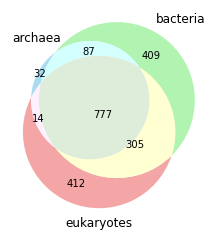

In [9]:
# Create a Venn diagram for three sets
venn3(subsets=[a, b, e], set_labels=('archaea', 'bacteria', 'eukaryotes'),
      set_colors=('skyblue', 'lightgreen', 'lightcoral'), alpha=0.7)

# plt.savefig('vennALL.png')
plt.show()

In [10]:
ab = a & b
be = b & e
ae = a & e
abe = a & b & e

print(f'len(ab) = {len(ab)}')
print(f'len(be) = {len(be)}')
print(f'len(ae) = {len(ae)}')
print(f'len(abe) = {len(abe)}')

len(ab) = 864
len(be) = 1082
len(ae) = 791
len(abe) = 777


In [11]:
a_fo = set()
for fold in a:
    if fold in xgroup2ne['NONE'].keys():
        a_fo.add(fold)

b_fo = set()
for fold in b:
    if fold in xgroup2ne['NONE'].keys():
        b_fo.add(fold)

e_fo = set()
for fold in e:
    if fold in xgroup2ne['NONE'].keys():
        e_fo.add(fold)

In [12]:
print('Metabolic Enzyme Folds')
print('----------------------')
print(f'len(archaea) = {len(a_fo)}')
print(f'len(bacteria) = {len(b_fo)}')
print(f'len(eukaryotes) = {len(e_fo)}')
print(f'len(all) = {len(a_fo | b_fo | e_fo)}')

# print(f'len(ab) = {len(a_fo & b_fo)}')
# print(f'len(be) = {len(b_fo & e_fo)}')
# print(f'len(ae) = {len(e_fo & a_fo)}')
# print(f'len(abe) = {len(e_fo & a_fo & b_fo)}')

Metabolic Enzyme Folds
----------------------
len(archaea) = 357
len(bacteria) = 391
len(eukaryotes) = 371
len(all) = 397


In [13]:
print(a_fo - (b_fo | e_fo))  # archaea only: {'5103'}
print(b_fo - (a_fo | e_fo))  # bacteria only: {'4036', '4035', '914', '3018', '582', '6051', '3339', '4054', '640', '6113', '1055', '3847', '6174'}
print(e_fo - (b_fo | a_fo))  # eukaryotes only: {'3322', '3257', '558', '3777', '3371'}

{'5103'}
{'4036', '6051', '4035', '914', '3847', '4054', '6113', '3018', '582', '3339', '1055', '640', '6174'}
{'3371', '558', '3777', '3322', '3257'}


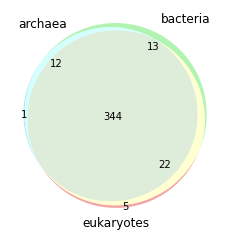

In [14]:
# Create a Venn diagram for three sets
venn3(subsets=[a_fo, b_fo, e_fo], set_labels=('archaea', 'bacteria', 'eukaryotes'),
      set_colors=('skyblue', 'lightgreen', 'lightcoral'), alpha=0.7)

# plt.savefig('venn397.png')
plt.show()

In [15]:
print('ALL ECOD Domains (v.379)')
print('----------------------')
print(f'len(archaea) = {len(a)}')
print(f'len(bacteria) = {len(b)}')
print(f'len(eukaryotes) = {len(e)}')
print(f'len(all) = {len(a | b | e)}')

ALL ECOD Domains (v.379)
----------------------
len(archaea) = 910
len(bacteria) = 1578
len(eukaryotes) = 1508
len(all) = 2036


In [16]:
KEGG397 = a_fo|b_fo|e_fo
xgroup2ds_a_397 = {}
xgroup2ds_b_397 = {}

for key in xgroup2ds_a.keys():
    if key in KEGG397:
        xgroup2ds_a_397[key] = xgroup2ds_a[key]
        
for key in xgroup2ds_b.keys():
    if key in KEGG397:
        xgroup2ds_b_397[key] = xgroup2ds_b[key]

ds_archaea vs. ds_bacteria: corr = 0.815456756461165, p_value = 7.861723e-96


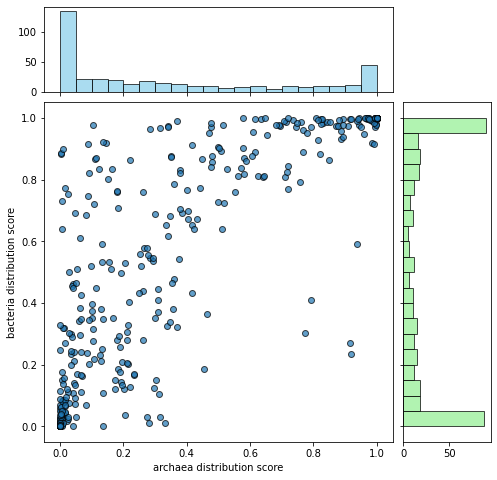

In [21]:
corr, p = pearson(xgroup2ds_a_397, xgroup2ds_b_397)
print(f'ds_archaea vs. ds_bacteria: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ds_a_397, xgroup2ds_b_397)
x = data1
y = data2

# Create a 2x2 grid layout
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(x, y, edgecolor='k', alpha=0.7)
ax_scatter.set_xlabel('archaea distribution score')
ax_scatter.set_ylabel('bacteria distribution score')

# Histogram on the bottom
ax_hist_bottom = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_hist_bottom.hist(x, bins=20, edgecolor='k', color='skyblue', alpha=0.7)

# Histogram on the left
ax_hist_left = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_hist_left.hist(y, bins=20, orientation='horizontal', edgecolor='k', color='lightgreen', alpha=0.7)

# Remove x-axis label from the histogram on the bottom
plt.setp(ax_hist_bottom.get_xticklabels(), visible=False)

# Remove y-axis label from the histogram on the left
plt.setp(ax_hist_left.get_yticklabels(), visible=False)

# plt.savefig('ds_ArchaeaVsBacteria.png')
plt.show()

# cumulative affinity

In [17]:
xgroup2ne['NONE']['2002']

[2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [18]:
len(xgroup2ne['NONE']['2002'])

1001

In [19]:
i_to_x = {}
for xgroup in xgroup2ne['NONE'].keys():
    for i in xgroup2ne['NONE'][xgroup]:
        if i not in i_to_x:
            i_to_x[i] = [xgroup]
        else:
            i_to_x[i].append(xgroup)
        

In [20]:
i_to_x[2]

['2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 '2002',
 

In [21]:
# original

i_to_e = {}
i_to_abe = {}
for i in i_to_x:
    num_e = 0
    num_abe = 0
    for x in i_to_x[i]:
        if x in abe:
            num_abe += 1
        elif x in e:
            num_e += 1
        else:  # (a or b) - abe
            continue
    try:
        e_fraction = num_e / (num_abe + num_e)
        abe_fraction = num_abe / (num_abe + num_e)
        i_to_e[i] = e_fraction
        i_to_abe[i] = abe_fraction
    except:
        i_to_e[i] = 0
        i_to_abe[i] = 0 

                       abe         e
injection number                    
2                 1.000000  0.000000
3                 1.000000  0.000000
4                 1.000000  0.000000
5                 1.000000  0.000000
6                 1.000000  0.000000
...                    ...       ...
354               0.926189  0.073811
355               0.899721  0.100279
356               0.795706  0.204294
357               0.703766  0.296234
371               0.000000  0.000000

[370 rows x 2 columns]


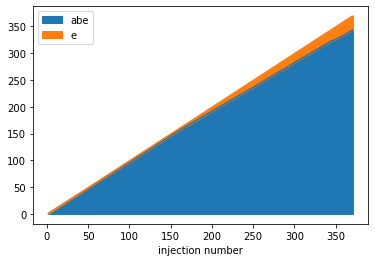

In [22]:
df1 = pd.DataFrame(list(i_to_abe.items()), columns=['injection number', 'abe']).set_index('injection number')
df2 = pd.DataFrame(list(i_to_e.items()), columns=['injection number', 'e']).set_index('injection number')

# Concatenate the DataFrames horizontally
df = pd.concat([df1, df2], axis=1, ignore_index=False)
print(df)

pt = pd.pivot_table(df, index='injection number', values=['abe', 'e'], fill_value=0)
pt = pt.cumsum()
pt.plot.area()
# plt.savefig('phyletic_affinity_cumulative.png')
plt.show()

In [23]:
# e only 

i_to_e2 = {}
i_to_abe2 = {}
e_only = e - a - b
for i in i_to_x:
    num_e = 0
    num_abe = 0
    for x in i_to_x[i]:
        if x in abe:
            num_abe += 1
        elif x in e_only:
            num_e += 1
        else:
            continue
    try:
        e_fraction = num_e / (num_abe + num_e)
        abe_fraction = num_abe / (num_abe + num_e)
        i_to_e2[i] = e_fraction
        i_to_abe2[i] = abe_fraction
    except:
        i_to_e2[i] = 0
        i_to_abe2[i] = 0 

                  abe    e
injection number          
2                 1.0  0.0
3                 1.0  0.0
4                 1.0  0.0
5                 1.0  0.0
6                 1.0  0.0
...               ...  ...
354               1.0  0.0
355               1.0  0.0
356               1.0  0.0
357               1.0  0.0
371               0.0  0.0

[370 rows x 2 columns]


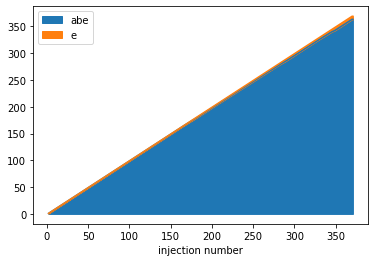

In [24]:
df1 = pd.DataFrame(list(i_to_abe2.items()), columns=['injection number', 'abe']).set_index('injection number')
df2 = pd.DataFrame(list(i_to_e2.items()), columns=['injection number', 'e']).set_index('injection number')

# Concatenate the DataFrames horizontally
df = pd.concat([df1, df2], axis=1, ignore_index=False)
print(df)

pt = pd.pivot_table(df, index='injection number', values=['abe', 'e'], fill_value=0)
pt = pt.cumsum()
pt.plot.area()
# plt.savefig('phyletic_affinity_cumulative.png')
plt.show()

In [25]:
print(df['abe'])

injection number
2      1.0
3      1.0
4      1.0
5      1.0
6      1.0
      ... 
354    1.0
355    1.0
356    1.0
357    1.0
371    0.0
Name: abe, Length: 370, dtype: float64


In [26]:
len(e_only)

412

In [27]:
# e only + fraction of ALL 

i_to_e3 = dict()
i_to_abe3 = dict()
e_only = e - a - b
for i in i_to_x:
    num_e = 0
    num_abe = 0
    num_else = 0
    for x in i_to_x[i]:
        if x in abe:
            num_abe += 1
        elif x in e_only:
            num_e += 1
        else:
            num_else += 1
    try:
        e_fraction = num_e / (num_e + num_abe + num_else)
        abe_fraction = num_abe / (num_e + num_abe + num_else)
        i_to_e3[i] = e_fraction
        i_to_abe3[i] = abe_fraction
    except:
        i_to_e3[i] = 0
        i_to_abe3[i] = 0 

In [28]:
i_to_abe3

{2: 1.0,
 3: 1.0,
 4: 1.0,
 5: 1.0,
 6: 1.0,
 7: 1.0,
 8: 1.0,
 13: 1.0,
 15: 1.0,
 14: 1.0,
 10: 1.0,
 11: 1.0,
 9: 1.0,
 12: 1.0,
 16: 1.0,
 17: 1.0,
 18: 1.0,
 19: 1.0,
 20: 1.0,
 21: 1.0,
 22: 1.0,
 23: 1.0,
 24: 1.0,
 25: 1.0,
 26: 1.0,
 27: 1.0,
 30: 1.0,
 29: 1.0,
 28: 1.0,
 33: 0.968031968031968,
 31: 1.0,
 32: 1.0,
 34: 0.951048951048951,
 35: 0.8961038961038961,
 36: 0.8541458541458542,
 37: 0.8661338661338661,
 38: 0.8761238761238761,
 39: 0.8691308691308691,
 41: 0.8551448551448552,
 40: 0.8641358641358642,
 42: 1.0,
 45: 1.0,
 43: 1.0,
 48: 1.0,
 47: 1.0,
 44: 1.0,
 46: 1.0,
 49: 1.0,
 50: 1.0,
 51: 1.0,
 63: 1.0,
 57: 1.0,
 58: 1.0,
 59: 1.0,
 56: 1.0,
 53: 1.0,
 64: 1.0,
 52: 1.0,
 54: 1.0,
 55: 1.0,
 60: 1.0,
 62: 1.0,
 61: 1.0,
 65: 1.0,
 66: 0.9230769230769231,
 70: 0.9140859140859141,
 95: 0.9560439560439561,
 74: 0.932067932067932,
 88: 0.9430569430569431,
 82: 0.926073926073926,
 69: 0.9200799200799201,
 76: 0.9330669330669331,
 89: 0.9430569430569431,
 86: 0.93706

In [29]:
i_to_e3

{2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0.0,
 6: 0.0,
 7: 0.0,
 8: 0.0,
 13: 0.0,
 15: 0.0,
 14: 0.0,
 10: 0.0,
 11: 0.0,
 9: 0.0,
 12: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.0,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.0,
 24: 0.0,
 25: 0.0,
 26: 0.0,
 27: 0.0,
 30: 0.0,
 29: 0.0,
 28: 0.0,
 33: 0.0,
 31: 0.0,
 32: 0.0,
 34: 0.0,
 35: 0.0,
 36: 0.0,
 37: 0.0,
 38: 0.0,
 39: 0.0,
 41: 0.0,
 40: 0.0,
 42: 0.0,
 45: 0.0,
 43: 0.0,
 48: 0.0,
 47: 0.0,
 44: 0.0,
 46: 0.0,
 49: 0.0,
 50: 0.0,
 51: 0.0,
 63: 0.0,
 57: 0.0,
 58: 0.0,
 59: 0.0,
 56: 0.0,
 53: 0.0,
 64: 0.0,
 52: 0.0,
 54: 0.0,
 55: 0.0,
 60: 0.0,
 62: 0.0,
 61: 0.0,
 65: 0.0,
 66: 0.0,
 70: 0.0,
 95: 0.0,
 74: 0.0,
 88: 0.0,
 82: 0.0,
 69: 0.0,
 76: 0.0,
 89: 0.0,
 86: 0.0,
 93: 0.0,
 83: 0.0,
 73: 0.0,
 68: 0.0,
 81: 0.0,
 67: 0.0,
 72: 0.0,
 91: 0.0,
 78: 0.0,
 80: 0.0,
 90: 0.0,
 79: 0.0,
 77: 0.0,
 71: 0.0,
 75: 0.0,
 92: 0.0,
 84: 0.0,
 85: 0.0,
 87: 0.0,
 94: 0.0,
 96: 0.0,
 97: 0.0,
 99: 0.0,
 98: 0.0,
 100: 0.0,
 101: 0.0,
 102: 

                       abe    e
injection number               
2                 1.000000  0.0
3                 1.000000  0.0
4                 1.000000  0.0
5                 1.000000  0.0
6                 1.000000  0.0
...                    ...  ...
354               0.677922  0.0
355               0.655838  0.0
356               0.662072  0.0
357               0.659989  0.0
371               0.000000  0.0

[370 rows x 2 columns]


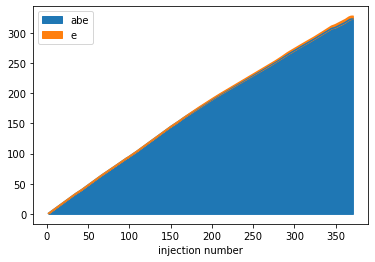

In [30]:
df1 = pd.DataFrame(list(i_to_abe3.items()), columns=['injection number', 'abe']).set_index('injection number')
df2 = pd.DataFrame(list(i_to_e3.items()), columns=['injection number', 'e']).set_index('injection number')

# Concatenate the DataFrames horizontally
df = pd.concat([df1, df2], axis=1, ignore_index=False)
print(df)

pt = pd.pivot_table(df, index='injection number', values=['abe', 'e'], fill_value=0)
pt = pt.cumsum()
pt.plot.area()
plt.show()

In [31]:
# e vs. a or b 

i_to_e = dict()
i_to_aorb = dict()
e_only = e - a - b
for i in i_to_x:
    num_e = 0
    num_aorb = 0
    num_else = 0
    for x in i_to_x[i]:
        if x in a or x in b:
            num_aorb += 1
        elif x in e_only:
            num_e += 1
        else:
            num_else += 1
    try:
        e_fraction = num_e / (num_e + num_aorb)
        aorb_fraction = num_aorb / (num_e + num_aorb)
        i_to_e[i] = e_fraction
        i_to_aorb[i] = aorb_fraction
    except:
        i_to_e[i] = 0
        i_to_aorb[i] = 0 

                  a or b    e
injection number             
2                    1.0  0.0
3                    1.0  0.0
4                    1.0  0.0
5                    1.0  0.0
6                    1.0  0.0
...                  ...  ...
354                  1.0  0.0
355                  1.0  0.0
356                  1.0  0.0
357                  1.0  0.0
371                  1.0  0.0

[370 rows x 2 columns]


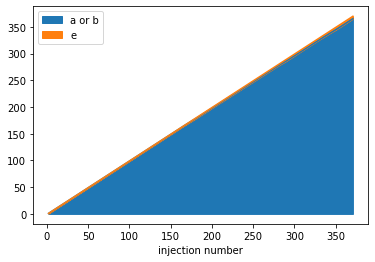

In [32]:
df1 = pd.DataFrame(list(i_to_aorb.items()), columns=['injection number', 'a or b']).set_index('injection number')
df2 = pd.DataFrame(list(i_to_e.items()), columns=['injection number', 'e']).set_index('injection number')

# Concatenate the DataFrames horizontally
df = pd.concat([df1, df2], axis=1, ignore_index=False)
print(df)

pt = pd.pivot_table(df, index='injection number', values=['a or b', 'e'], fill_value=0)
pt = pt.cumsum()
pt.plot.area()
plt.show()

# Comparing DS (distribution score) methods

Here, we compare the distribution scores obtained by 3 methods:

- (1) **50%** method: fraction of the phyla where the fold exists in >50% of the genomes within a phylum
- (2) **noPhyla** method: fraction of genomes with the given fold
- (3) **average** method: calculate the fraction of genomes with the given fold in each phylum -> take average of DS across all phyla

In [33]:
# DS_50%
a_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_bacteria_recovered.csv'

# DS_average
a_ave_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_ave_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'

# DS_noPhyla
a_noPhyla_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_archaea_recovered.csv'
b_noPhyla_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_bacteria_recovered.csv'

In [34]:
# DS_50%
xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))

# average
xgroup2ds_a_ave = csv2dict(a_ave_path)
print(len(xgroup2ds_a_ave))
xgroup2ds_b_ave = csv2dict(b_ave_path)
print(len(xgroup2ds_b_ave))

# noPhyla
xgroup2ds_a_noPhyla = csv2dict(a_noPhyla_path)
print(len(xgroup2ds_a_noPhyla))
xgroup2ds_b_noPhyla = csv2dict(b_noPhyla_path)
print(len(xgroup2ds_b_noPhyla))

2230
2230
2230
2230
2230
2230


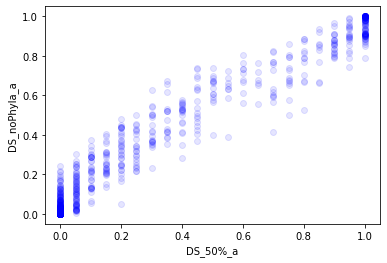

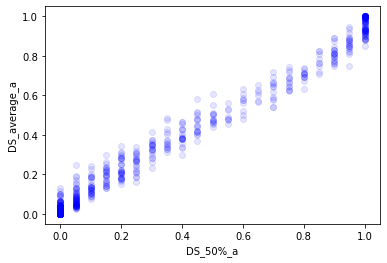

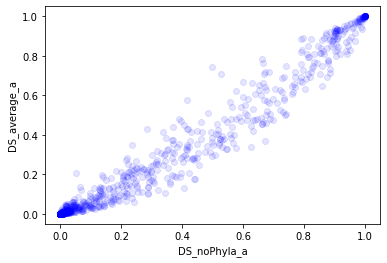

In [35]:
# archaea
scatter(xgroup2ds_a, xgroup2ds_a_noPhyla, 'DS_50%_a', 'DS_noPhyla_a')
scatter(xgroup2ds_a, xgroup2ds_a_ave, 'DS_50%_a', 'DS_average_a')
scatter(xgroup2ds_a_noPhyla, xgroup2ds_a_ave, 'DS_noPhyla_a', 'DS_average_a')

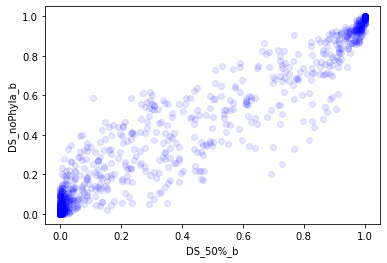

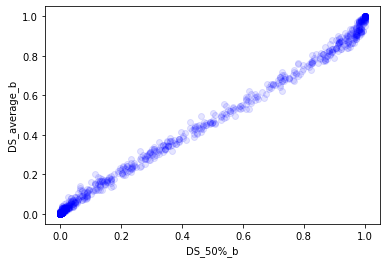

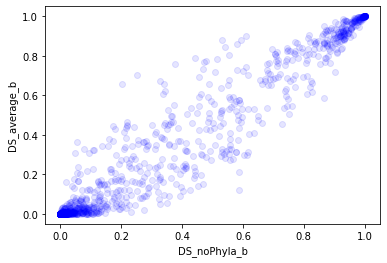

In [36]:
# bacteria
scatter(xgroup2ds_b, xgroup2ds_b_noPhyla, 'DS_50%_b', 'DS_noPhyla_b')
scatter(xgroup2ds_b, xgroup2ds_b_ave, 'DS_50%_b', 'DS_average_b')
scatter(xgroup2ds_b_noPhyla, xgroup2ds_b_ave, 'DS_noPhyla_b', 'DS_average_b')

- DS_average & DS_50% give similar scores
- noPhyla method seems to introduce biases, because it does not give equal weights to phyla with more or less genomes